In [8]:
import os
import glob
import random
from pathlib import Path
import numpy as np
from scipy.stats import kruskal
from scipy.stats import ttest_1samp
import pandas as pd

import scanpy as sc
import anndata

import sys
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')
from utils_pheno import * 

import warnings
warnings.filterwarnings("ignore")

In [14]:
save_prefix = '/cephfs/volumes/hpc_data_prj/cb_microbiome/3d70379f-bb3a-4d40-9908-3b0496384f42/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/miloR'

In [4]:
file_path = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)
leiden_columns = [col for col in adata_normal.obs.columns if 'top_samples' not in col]
data = adata_normal.obs.loc[:, leiden_columns]
data.columns = data.columns.str.replace('.', '', regex=False)
leiden_columns = [col for col in data.columns if col.startswith('leiden_')]
data[leiden_columns] = data[leiden_columns].apply(pd.to_numeric, errors='coerce')

agg_df = pd.read_csv(f"/cephfs/volumes/hpc_data_prj/cb_microbiome/3d70379f-bb3a-4d40-9908-3b0496384f42/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/NBTs_atlas/leiden_0.5_nuclei_morphology_patchAggregate.csv")

agg_df_leiden = pd.merge(agg_df, data, on='patch_id', how='left')
agg_df_leiden

,patch_id,area_mean,bbox_area_mean,extent_mean,eccentricity_mean,perimeter_mean,major_axis_length_mean,minor_axis_length_mean,solidity_mean,circularity_mean,...,cohort_y,wsi_id_y,source_y,leiden_05,umap1,umap2,leiden_10,leiden_15,leiden_20,risk
0,17027148_FPE_1_33274_15932_8580_7424_58_36_578,435.666667,636.750000,0.682728,0.744726,79.756271,30.183980,18.317316,0.951935,5.980464,...,KHP,17027148_FPE_1,N_RM,1,7.040086,9.286973,0,14,6,0
1,17027148_FPE_1_33274_15932_8580_7424_69_39_578,393.000000,565.666667,0.683787,0.809851,75.745863,28.951985,16.680905,0.948906,5.573351,...,KHP,17027148_FPE_1,N_RM,2,12.466032,7.988068,10,15,27,0
2,17027148_FPE_2_12580_1986_92469_86893_100_80_555,795.000000,1050.000000,0.756404,0.859368,115.547727,45.988648,22.576476,0.946489,4.837108,...,KHP,17027148_FPE_2,N_RM,2,11.808797,6.497365,9,6,15,0
3,17027148_FPE_2_12580_1986_92469_86893_105_90_555,515.000000,667.000000,0.772114,0.617495,83.012193,28.899565,22.731678,0.969868,7.748800,...,KHP,17027148_FPE_2,N_RM,2,12.109770,8.361293,10,15,27,0
4,17027148_FPE_2_12580_1986_92469_86893_181_96_555,239.333333,398.666667,0.622276,0.916548,65.941125,28.244730,10.918448,0.940453,3.853194,...,KHP,17027148_FPE_2,N_RM,2,10.952459,6.093318,9,6,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15390,BRACS_762_N_2_256_1024,318.695652,423.608696,0.753841,0.661133,65.824550,23.828278,16.982267,0.958852,7.109373,...,BRCAS,BRACS_762_N_2,N,3,4.707575,1.461277,1,5,18,2
15391,BRACS_762_N_2_256_256,287.913580,397.037037,0.733014,0.749787,63.879283,24.339661,14.999238,0.954105,6.201756,...,BRCAS,BRACS_762_N_2,N,5,2.778962,1.968275,1,7,3,2
15392,BRACS_773_N_33_1024_512,274.593023,376.267442,0.737896,0.686913,61.592039,22.759832,15.385053,0.955000,6.812176,...,BRCAS,BRACS_773_N_33,N,5,2.299118,3.228929,4,4,24,2
15393,BRACS_773_N_33_1536_256,270.870130,372.675325,0.733889,0.702952,61.010779,22.740114,15.093026,0.956082,6.691140,...,BRCAS,BRACS_773_N_33,N,5,-1.050461,3.728693,11,16,16,2


In [6]:
cluster_order_0 = ['0', '1', '2', '3', '4', '5']
cluster_order_1 = ['8', '0', '7', '12', '3', '10', '2', '9', '1', '4', '5', '6', '11']
cluster_order_2 = ['12', '20', '1', '13', '14', '9', '18', '19', '8', '11', '15', '0', '6', '4', '7', '3', '16', '2', '5', '10', '17', '21']
cluster_order_3 = ['10', '26', '1', '11', '29', '6', '28', '8', '23', '17', '14', '21', '9', '22', '27', '0', '13', '15', '30', '7', '20', '3', '2', '16', '4', '12', '5', '18', '24', '19', '25', '31']

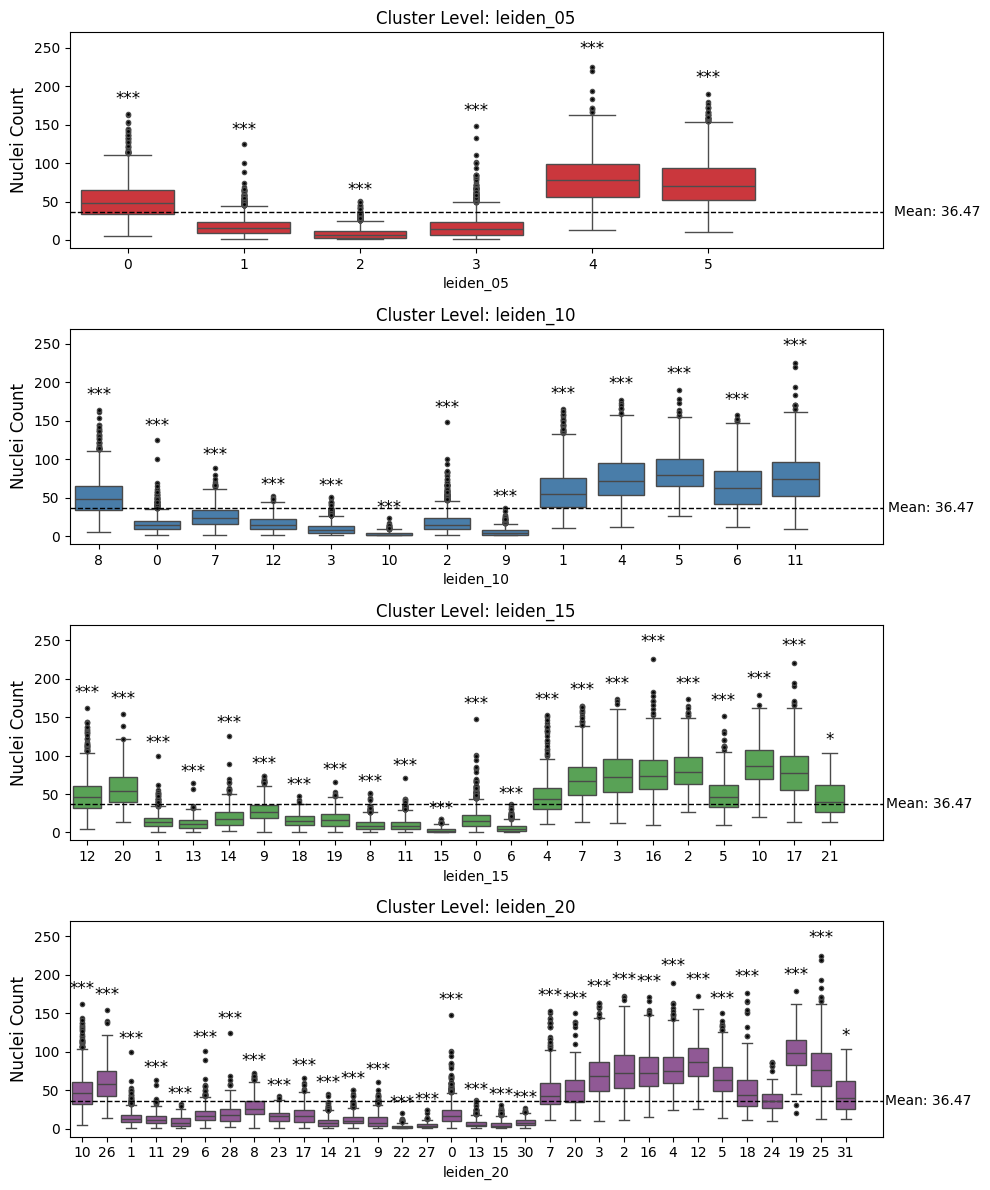

In [28]:
# Step 1: Compute overall mean
overall_mean = agg_df_leiden['nuclei_count'].mean()

# Cluster config
cluster_levels = ['leiden_05', 'leiden_10', 'leiden_15', 'leiden_20']
cluster_orders = [cluster_order_0, cluster_order_1, cluster_order_2, cluster_order_3]
colors = ['#E21F26', '#397FB9', '#4EAF49', '#984F9F']

# Convert cluster labels to string
for level in cluster_levels:
    agg_df_leiden[level] = agg_df_leiden[level].astype(str)

# Plot setup
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    sns.boxplot(
        x=level, y='nuclei_count',
        data=agg_df_leiden, order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )
    
    axes[i].set_ylabel('Nuclei Count', fontsize=12)
    axes[i].set_title(f"Cluster Level: {level}", fontsize=12)
    
    # Draw overall mean line
    axes[i].axhline(y=overall_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, overall_mean, f"Mean: {overall_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster]['nuclei_count']
        
        if len(cluster_vals) > 1:
            tstat, pval = ttest_1samp(cluster_vals, overall_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                # Ensure stars fit inside plot
                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/nuclei_counts_4levels_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

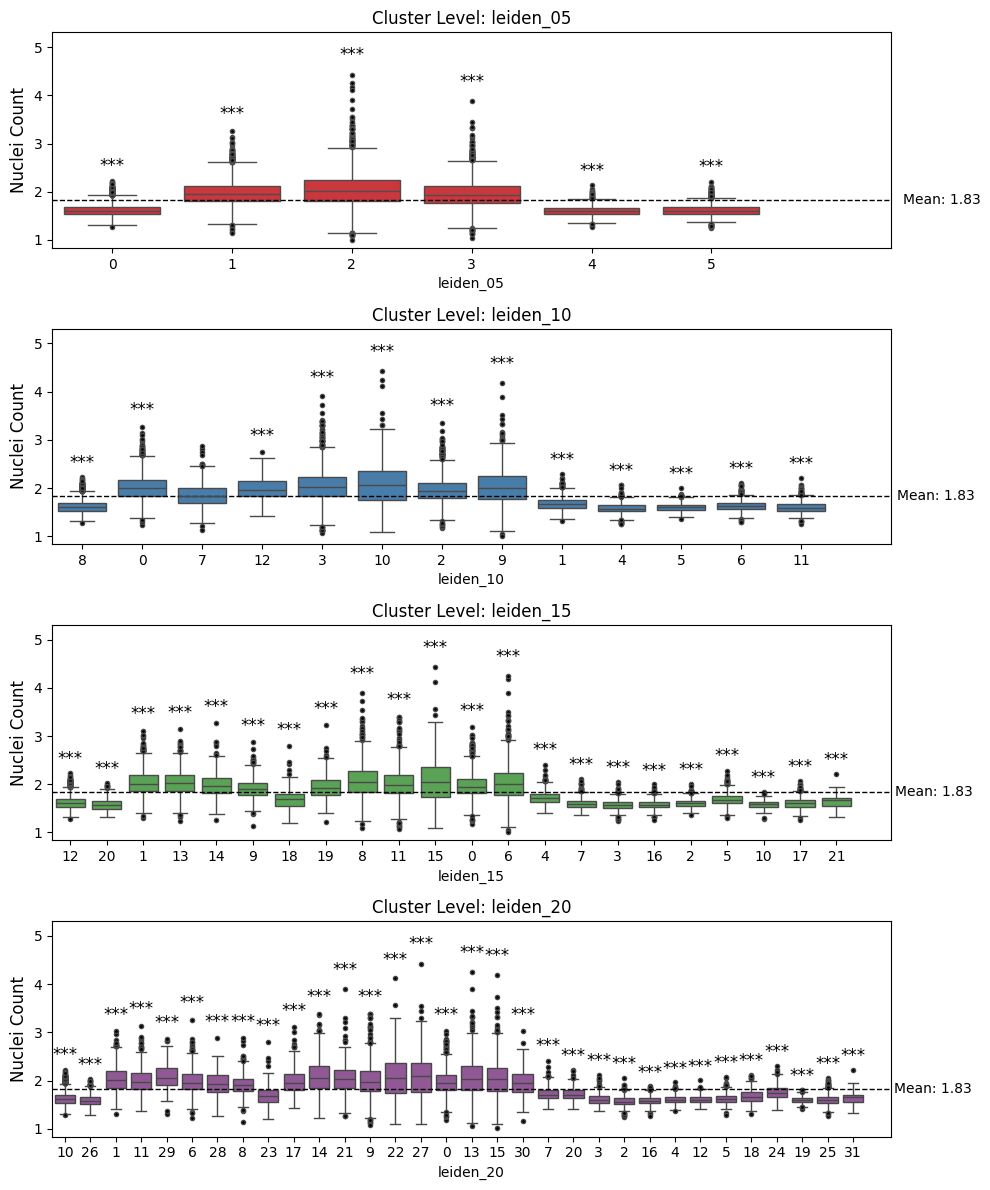

In [30]:
# Step 1: Compute overall mean
overall_mean = agg_df_leiden['elongation_mean'].mean()

# Cluster config
cluster_levels = ['leiden_05', 'leiden_10', 'leiden_15', 'leiden_20']
cluster_orders = [cluster_order_0, cluster_order_1, cluster_order_2, cluster_order_3]
colors = ['#E21F26', '#397FB9', '#4EAF49', '#984F9F']

# Convert cluster labels to string
for level in cluster_levels:
    agg_df_leiden[level] = agg_df_leiden[level].astype(str)

# Plot setup
fig, axes = plt.subplots(4, 1, figsize=(10, 12))
flierprops = dict(marker='o', markerfacecolor='black', markersize=3, linestyle='none')

for i, (level, order, color) in enumerate(zip(cluster_levels, cluster_orders, colors)):
    sns.boxplot(
        x=level, y='elongation_mean',
        data=agg_df_leiden, order=order,
        ax=axes[i], color=color,
        flierprops=flierprops
    )
    
    axes[i].set_ylabel('Nuclei Count', fontsize=12)
    axes[i].set_title(f"Cluster Level: {level}", fontsize=12)
    
    # Draw overall mean line
    axes[i].axhline(y=overall_mean, color='black', linestyle='--', linewidth=1)
    axes[i].text(len(order) + 0.6, overall_mean, f"Mean: {overall_mean:.2f}",
                 ha='left', va='center', fontsize=10, color='black')
    axes[i].set_xlim(-0.5, len(order) + 0.5)

    for j, cluster in enumerate(order):
        cluster_vals = agg_df_leiden[agg_df_leiden[level] == cluster]['elongation_mean']
        
        if len(cluster_vals) > 1:
            tstat, pval = ttest_1samp(cluster_vals, overall_mean)
            
            stars = ''
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            
            if stars:
                y_max = cluster_vals.max()
                y_star = y_max + 0.05 * y_max

                # Ensure stars fit inside plot
                current_ylim_top = axes[i].get_ylim()[1]
                if y_star > current_ylim_top:
                    axes[i].set_ylim(top=y_star + 0.15 * y_max)

                axes[i].text(j, y_star, stars,
                             ha='center', va='bottom',
                             fontsize=12, color='black')

plt.tight_layout()
save_pt = f"{save_prefix}/nuclei_elongation_4levels_boxplot.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()